# Mortgages Quality Trends (2000 - 2007)

## Goal 

    Investigating weather Mortgages Quality become Worst Over 2008 crisis by analyzing how key loan characterisitcs changed over year.

## Outputs

- Key trend charts saved to outputs/
 
    

In [1]:
#Imporing Libraries
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
df = pd.read_pickle("../data/processed/master.pkl")

In [3]:
df.shape

(550000, 22)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550000 entries, 0 to 549999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CREDIT_SCORE      548406 non-null  float64
 1   FIRST_PYMT_DATE   550000 non-null  int64  
 2   FIRST_TIME_BUYER  550000 non-null  str    
 3   MI_PCT            549988 non-null  float64
 4   NUM_UNITS         549991 non-null  float64
 5   OCC_STATUS        550000 non-null  str    
 6   OCLTV             549967 non-null  float64
 7   DTI               520002 non-null  float64
 8   UPB               550000 non-null  int64  
 9   LTV               550000 non-null  int64  
 10  INTEREST_RATE     550000 non-null  float64
 11  CHANNEL           550000 non-null  str    
 12  PROPERTY_STATE    550000 non-null  str    
 13  PROPERTY_TYPE     550000 non-null  str    
 14  LOAN_SEQ_NUM      550000 non-null  str    
 15  LOAN_PURPOSE      550000 non-null  str    
 16  LOAN_TERM         550000 non-nu

In [8]:
df.isnull().sum() 

CREDIT_SCORE         1594
FIRST_PYMT_DATE         0
FIRST_TIME_BUYER        0
MI_PCT                 12
NUM_UNITS               9
OCC_STATUS              0
OCLTV                  33
DTI                 29998
UPB                     0
LTV                     0
INTEREST_RATE           0
CHANNEL                 0
PROPERTY_STATE          0
PROPERTY_TYPE           0
LOAN_SEQ_NUM            0
LOAN_PURPOSE            0
LOAN_TERM               0
NUM_BORROWERS         166
ORIG_YEAR               0
MAX_DELINQ              0
ZERO_BAL            13251
PERF_MONTHS             0
dtype: int64

In [6]:
df.isnull().sum() /len(df) *100

CREDIT_SCORE        0.289818
FIRST_PYMT_DATE     0.000000
FIRST_TIME_BUYER    0.000000
MI_PCT              0.002182
NUM_UNITS           0.001636
OCC_STATUS          0.000000
OCLTV               0.006000
DTI                 5.454182
UPB                 0.000000
LTV                 0.000000
INTEREST_RATE       0.000000
CHANNEL             0.000000
PROPERTY_STATE      0.000000
PROPERTY_TYPE       0.000000
LOAN_SEQ_NUM        0.000000
LOAN_PURPOSE        0.000000
LOAN_TERM           0.000000
NUM_BORROWERS       0.030182
ORIG_YEAR           0.000000
MAX_DELINQ          0.000000
ZERO_BAL            2.409273
PERF_MONTHS         0.000000
dtype: float64

# Missing Value Analysis 

After Replacing Datasets missing placeholder values for specified fields which can be reffered fro missing codes in features we have got small number of features containing the missing values. Most column have negligible misssing values with excetion of DTI(5.45%) and ZERO_BAL(2.41%).

Currently we are going to original data trends so we are not doing any nan handling yet to preserve original data distributions. Since Pandas and matplolib automatically ingnores NaN when computing the statistics and genrating visualization. NaN handling will be done in data preprocessing stage.

Currently we dont have **DEFAULT_FLAG** in data set to confirm weather laon was defaulted or not so we will have create a **DEFAULT_FLAG** column using the extracted features **MAX_DELINQ** and **ZERO_BAL**

**Condition 1 : MAX_DELINQ >= "3"**

Delinquency status of **3** means the borrower is **90+ days past due**. This is the industry standard definition of serious delinquency,statistically most loans that hit 90 days never recover.

**NOTE : - DELINQ_STATUS loaded as string because it contains non-numeric values like RA (REO Acquisition) and XX.String comparison of "3" >= "3" still works correctly for our purposes since we just need to identify 3 and above.**

**Here RA → bank has already taken the property,
XX → loan has been removed from the portfolio.**

**Condition 2 : ZERO_BAL is 03 or 09**

Some loans never show high delinquency in our data but still ended in foreclosure or REO.The zero balance code confirms the final outcome.


THESE ARE INDUSTRIAL STANDARDS FOR USED FIELDS.

In [9]:
# Default Flag 
df["DEFAULT_FLAG"] = ((df["MAX_DELINQ"] >="3") | (df["ZERO_BAL"].isin(["03","09"])) ).astype(int)

print(df["DEFAULT_FLAG"].value_counts())

DEFAULT_FLAG
0    510640
1     39360
Name: count, dtype: int64


# DEFAULT_FLAG distribution 

out of 550K loans originated between 2000 to 2010 :
- 510,640 loans remained current and paid of normally which is ~ 92.8%
- 39,360  loans defaulted through deliquency or foreclosure whic is ~ 7.2%

This 7.2% overall default rates are expted during this time period.The rates will look very different when broken down by year.

In [10]:
df.groupby("ORIG_YEAR")["DEFAULT_FLAG"].mean().mul(100).round(2)

ORIG_YEAR
2000     3.49
2001     3.22
2002     3.39
2003     4.05
2004     7.09
2005    10.99
2006    14.33
2007    16.46
2008     9.29
2009     3.17
2010     3.23
Name: DEFAULT_FLAG, dtype: float64

<Axes: title={'center': 'Number of Defaulted loan by origination year'}, xlabel='Origination Year', ylabel='Count of Defaulted loans'>

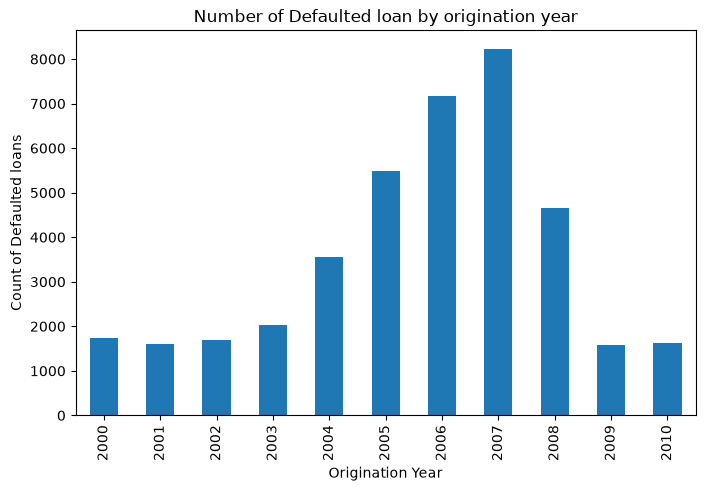

In [21]:
df[df["DEFAULT_FLAG"] == 1].groupby("ORIG_YEAR")["DEFAULT_FLAG"].count().plot(
    xlabel="Origination Year",
    ylabel="Count of Defaulted loans",
    kind="bar",
    figsize=(8,5),
    title="Number of Defaulted loan by origination year"
)

# OBSERVATIONS

From above results we can see that the Number Of Defaulted Loan originated during the duration 2004 to 2008 are significantly high compared to other origination year.

- The default rates stedily incresed from 7.09% in 2004 to peak of 16.46% in 2007
- After 2007 defaulted loans reduced significantly .
- This trend align 2007 - 2008 financial crisis, durring which the standards weakened and defaults increased.
